# 1st Summer School on Deep Learning: Shaping the Future of Artificial Intelligence

## Week 1, Practical Session III
21 May, 2025, 2.30 to 4.30 PM

This notebook demonstrates how to implement a simple feedforward neural network from scratch using only NumPy, without any object-oriented programming (i.e., no classes).

Key highlights:

  * Fully functional style: All functions (initialization, forward, backward, training, etc.) are standalone.

  * Iris dataset is used for multi-class classification (3 classes).

  * Labels are one-hot encoded, and the output layer uses softmax activation.

  * Categorical cross-entropy is used as the loss function.

  * Training is done using mini-batch gradient descent, with batch size, learning rate, and epochs as parameters.

  * The network architecture is a simple 2-layer MLP: input → hidden → output.

  * Accuracy and loss are tracked and can be visualized epoch-wise.

This approach helps build a clear understanding of how neural networks work under the hood, without relying on frameworks like TensorFlow or PyTorch.

## Iris Dataset

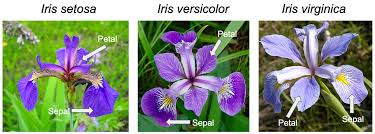

The Iris dataset is a classic benchmark in machine learning and statistics. It contains 150 samples of iris flowers from 3 different species:

* Setosa

* Versicolor

* Virginica

Each sample has 4 numerical features:

1. Sepal length (cm)

2. Sepal width (cm)

3. Petal length (cm)

4. Petal width (cm)

The target variable is a categorical label (0, 1, or 2), indicating the species. The dataset is balanced, with 50 samples per class.

### Let's start building MLP for classification if iris species

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [ ]:
# Load dataset
iris = load_iris()
X = iris.data  # all features
y = iris.target.reshape(-1, 1)  # 3-class labels


In [ ]:
# One-hot encode the targets
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)


In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Model parameters
input_size = X.shape[1]
hidden_size = 8
output_size = 3
lr = 0.1
epochs = 1000

# Activation functions
def get_activation_funcs(name):
    if name == 'sigmoid':
        act = lambda x: 1 / (1 + np.exp(-x))
        deriv = lambda x: x * (1 - x)
    elif name == 'tanh':
        act = np.tanh
        deriv = lambda x: 1 - x ** 2
    elif name == 'relu':
        act = lambda x: np.maximum(0, x)
        deriv = lambda x: np.where(x > 0, 1, 0)
    elif name == 'leaky_relu':
        act = lambda x: np.where(x > 0, x, 0.01 * x)
        deriv = lambda x: np.where(x > 0, 1, 0.01)
    else:
        raise ValueError("Unsupported activation")
    return act, deriv


In [ ]:
# Softmax for multi-class
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # stability
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [ ]:
# Cross-entropy for multi-class
def cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

In [ ]:
# Accuracy
def accuracy_score(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

In [ ]:
def train_model(activation_name):
    activation, activation_derivative = get_activation_funcs(activation_name)
    loss_history = []

    # Initialize weights
    np.random.seed(1)  # ensures same random weights every time you run the code
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    # Training loop
    for epoch in range(epochs):
        # Forward
        Z1 = np.dot(X_train, W1) + b1          # Z1= w1.x1 + b1
        A1 = activation(Z1)                    # A1 = relu(Z1)
        Z2 = np.dot(A1, W2) + b2               # Z2 = A1.W2 + b2
        A2 = softmax(Z2)                       # A2 = softmax(Z2)   -> final output by perceptron

        loss = cross_entropy(y_train, A2)
        loss_history.append(loss)

        # Backward
        dZ2 = A2 - y_train
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * activation_derivative(A1)
        dW1 = np.dot(X_train.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update weights
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # Predict function
    def predict(X):
        A1 = activation(np.dot(X, W1) + b1)
        A2 = softmax(np.dot(A1, W2) + b2)
        return A2

    # Evaluate
    y_pred = predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return loss_history, acc

In [ ]:
# Run for all activation functions
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
plt.figure(figsize=(12, 6))
accuracies = {}


<Figure size 1200x600 with 0 Axes>

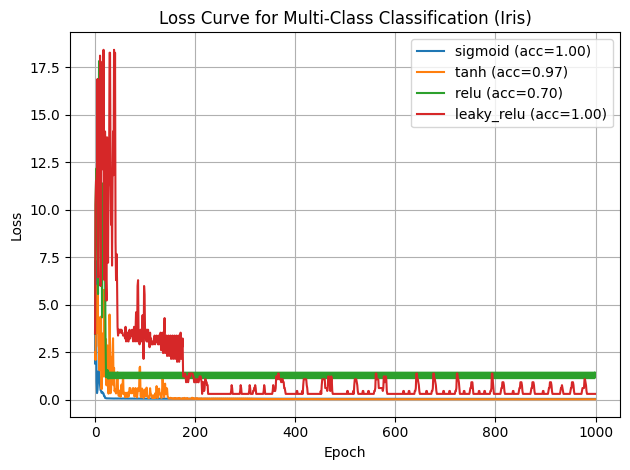


Test Accuracy per Activation Function:
sigmoid: 1.00
tanh: 0.97
relu: 0.70
leaky_relu: 1.00


In [ ]:
for act in activations:
    losses, acc = train_model(act)
    accuracies[act] = acc
    plt.plot(losses, label=f'{act} (acc={acc:.2f})')

# Plot losses
plt.title("Loss Curve for Multi-Class Classification (Iris)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print accuracy summary
print("\nTest Accuracy per Activation Function:")
for act, acc in accuracies.items():
    print(f"{act}: {acc:.2f}")